# 🛍️ Customer Segmentation Analysis

## Oasis Infobyte Data Analytics Internship – Task 2

### Objective

The objective of this project is to segment an e-commerce company's customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

The analysis aims to identify distinct customer groups and provide targeted marketing recommendations for each segment.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 📥 Data Loading and Initial Inspection

In [3]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# 2. 🧹 Data Cleaning and Preprocessing

In this section, the dataset is cleaned by handling missing values, removing cancelled transactions, and filtering invalid quantities and prices.

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df_clean = df_clean.dropna(subset=['Description'])

# Check dataset shape after removing missing values
print("Dataset Shape After Removing Missing Values:", df_clean.shape)

# Check remaining missing values
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

Dataset Shape After Removing Missing Values: (406829, 8)

Remaining Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [7]:
# Check cancelled transactions
cancelled_transactions = df_clean[
    df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Number of Cancelled Transactions:", len(cancelled_transactions))

# Check invalid quantities
print("\nTransactions with Quantity <= 0:",
      (df_clean['Quantity'] <= 0).sum())

# Check invalid prices
print("Transactions with UnitPrice <= 0:",
      (df_clean['UnitPrice'] <= 0).sum())

Number of Cancelled Transactions: 8905

Transactions with Quantity <= 0: 8905
Transactions with UnitPrice <= 0: 40


In [8]:
# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# Remove transactions with zero or negative quantity
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove transactions with zero or negative UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Check the cleaned dataset
print("Final Dataset Shape:", df_clean.shape)

print("\nCancelled Transactions Remaining:",
      df_clean['InvoiceNo'].astype(str).str.startswith('C').sum())

print("Transactions with Quantity <= 0:",
      (df_clean['Quantity'] <= 0).sum())

print("Transactions with UnitPrice <= 0:",
      (df_clean['UnitPrice'] <= 0).sum())

Final Dataset Shape: (397884, 8)

Cancelled Transactions Remaining: 0
Transactions with Quantity <= 0: 0
Transactions with UnitPrice <= 0: 0


# 3. 💰 Feature Engineering

A TotalAmount feature is created by multiplying Quantity by UnitPrice.

In [9]:
# Create TotalAmount column
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

# Display the first 5 rows
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
print("Dataset Shape:", df_clean.shape)

print("\nTotal Sales:", round(df_clean['TotalAmount'].sum(), 2))

print("\nTotalAmount Summary:")
print(df_clean['TotalAmount'].describe())

Dataset Shape: (397884, 9)

Total Sales: 8911407.9

TotalAmount Summary:
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64


# 4. 📊 Customer Purchasing Behaviour Analysis

Customer-level metrics are calculated to understand spending behaviour, purchase frequency, average purchase value, and customer lifetime value.

In [11]:
# Calculate customer-level metrics

customer_metrics = df_clean.groupby('CustomerID').agg(
    Total_Spend=('TotalAmount', 'sum'),
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Average_Purchase_Value=('TotalAmount', 'mean')
).reset_index()

# Calculate basic customer lifetime value
# For this project, CLV is represented by the customer's total spending
customer_metrics['Customer_Lifetime_Value'] = customer_metrics['Total_Spend']

# Display first 5 rows
customer_metrics.head()

,CustomerID,Total_Spend,Purchase_Frequency,Average_Purchase_Value,Customer_Lifetime_Value
0,12346.0,77183.60,1,77183.600000,77183.60
1,12347.0,4310.00,7,23.681319,4310.00
2,12348.0,1797.24,4,57.975484,1797.24
3,12349.0,1757.55,1,24.076027,1757.55
4,12350.0,334.40,1,19.670588,334.40


In [12]:
print("Number of Unique Customers:", customer_metrics['CustomerID'].nunique())

print("\nOverall Customer Metrics:")

print(
    "Average Purchase Value:",
    round(customer_metrics['Average_Purchase_Value'].mean(), 2)
)

print(
    "Average Purchase Frequency:",
    round(customer_metrics['Purchase_Frequency'].mean(), 2)
)

print(
    "Average Customer Lifetime Value:",
    round(customer_metrics['Customer_Lifetime_Value'].mean(), 2)
)

Number of Unique Customers: 4338

Overall Customer Metrics:
Average Purchase Value: 68.35
Average Purchase Frequency: 4.27
Average Customer Lifetime Value: 2054.27


# 5. 👥 RFM Analysis

RFM analysis is used to evaluate customers based on:

- **Recency:** Number of days since the customer's last purchase.
- **Frequency:** Number of unique purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

In [13]:
# Set a reference date one day after the latest purchase date
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Display first 5 rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [14]:
print("RFM Dataset Shape:", rfm.shape)

print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM Dataset Shape: (4338, 4)

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [15]:
# Select RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


# 6. ⚙️ Feature Scaling

The RFM features are standardized using StandardScaler before applying the K-Means clustering algorithm.

In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Standardize the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data into a DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


In [17]:
print("Scaled Data Summary:")
print(rfm_scaled_df.describe().round(2))

Scaled Data Summary:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean      0.00       0.00      0.00
std       1.00       1.00      1.00
min      -0.92      -0.43     -0.23
25%      -0.75      -0.43     -0.19
50%      -0.42      -0.30     -0.15
75%       0.49       0.09     -0.04
max       2.81      26.60     30.95


# 7. 📉 Determining the Optimal Number of Clusters

The Elbow Method is used to identify an appropriate number of clusters for the K-Means algorithm.

In [18]:
from sklearn.cluster import KMeans

# Store inertia values
inertia = []

# Test different values of K
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Display inertia values
for k, value in zip(k_values, inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 1: Inertia = 13014.00
K = 2: Inertia = 9012.64
K = 3: Inertia = 5439.30
K = 4: Inertia = 4092.14
K = 5: Inertia = 3118.28
K = 6: Inertia = 2472.57
K = 7: Inertia = 2022.41
K = 8: Inertia = 1742.37
K = 9: Inertia = 1445.63
K = 10: Inertia = 1303.39


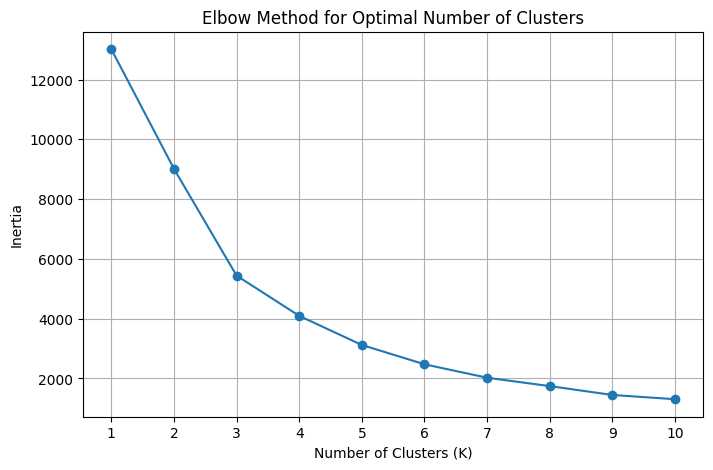

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

# 8. 🎯 K-Means Customer Segmentation

Based on the Elbow Method, K-Means clustering is applied using 4 customer segments.


In [20]:
# Apply K-Means clustering with 4 clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Create cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first 5 rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [21]:
# Count customers in each cluster

cluster_counts = (
    rfm['Cluster']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ['Cluster', 'Number_of_Customers']

print(cluster_counts)

   Cluster  Number_of_Customers
0        0                 3054
1        1                 1067
2        2                   13
3        3                  204


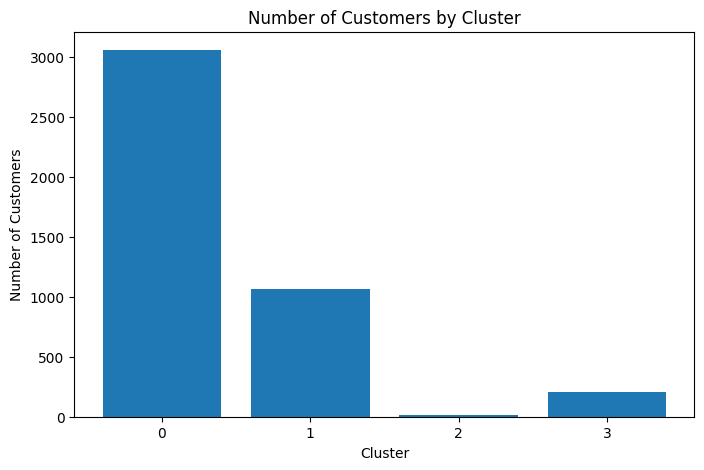

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts['Cluster'].astype(str),
    cluster_counts['Number_of_Customers']
)

plt.title('Number of Customers by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

# 9. 🔍 Cluster Profiling and Customer Segment Identification

Each cluster is analyzed based on its average Recency, Frequency, and Monetary values to understand customer behaviour and assign meaningful segment names.

### Customer Segment Interpretation

The clusters are interpreted using the following RFM characteristics:

- **Low Recency:** Customers who purchased recently.
- **High Recency:** Customers who have not purchased for a longer period.
- **High Frequency:** Customers who make purchases frequently.
- **High Monetary Value:** Customers who contribute higher revenue.

Based on these characteristics, the four clusters are labelled as Regular Customers, At-Risk Customers, VIP Customers, and Loyal Customers.

In [23]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

print(cluster_profile)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             3054        43.70           3.68       1359.05
1             1067       248.08           1.55        480.62
2               13         7.38          82.54     127338.31
3              204        15.50          22.33      12709.09


In [24]:
cluster_profile.reset_index()

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,3054,43.70,3.68,1359.05
1,1,1067,248.08,1.55,480.62
2,2,13,7.38,82.54,127338.31
3,3,204,15.50,22.33,12709.09


# 10. 📈 Customer Segment Visualization

The customer segments are visualized using different combinations of RFM features.

In [25]:
# Create meaningful customer segment names

segment_names = {
    0: 'Regular Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Loyal Customers'
}

# Add segment names to the RFM dataset
rfm['Segment'] = rfm['Cluster'].map(segment_names)

# Display the first 5 rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal Customers
1,12347.0,2,7,4310.00,0,Regular Customers
2,12348.0,75,4,1797.24,0,Regular Customers
3,12349.0,19,1,1757.55,0,Regular Customers
4,12350.0,310,1,334.40,1,At-Risk Customers


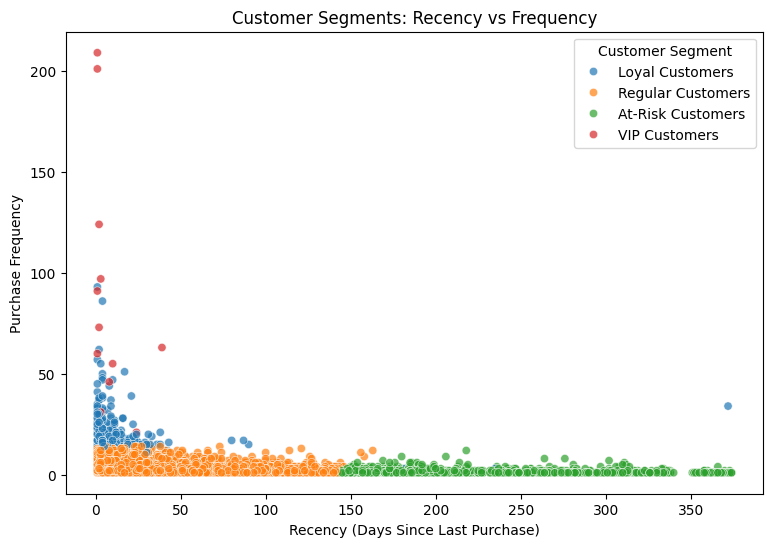

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    alpha=0.7
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Purchase Frequency')

plt.legend(title='Customer Segment')
plt.show()

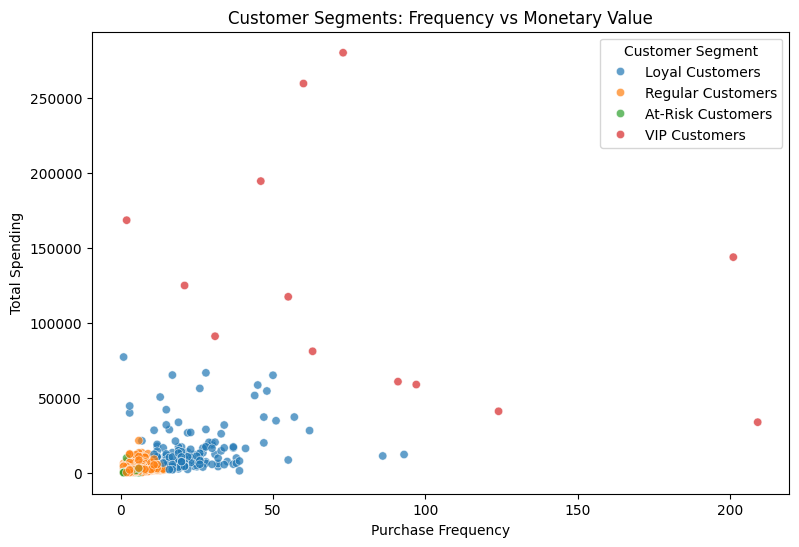

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    alpha=0.7
)

plt.title('Customer Segments: Frequency vs Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')

plt.legend(title='Customer Segment')
plt.show()

In [28]:
# Create a final cluster profile with segment names

final_profile = rfm.groupby(['Cluster', 'Segment']).agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

final_profile = final_profile.round(2)

final_profile

,Cluster,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,Regular Customers,3054,43.70,3.68,1359.05
1,1,At-Risk Customers,1067,248.08,1.55,480.62
2,2,VIP Customers,13,7.38,82.54,127338.31
3,3,Loyal Customers,204,15.50,22.33,12709.09


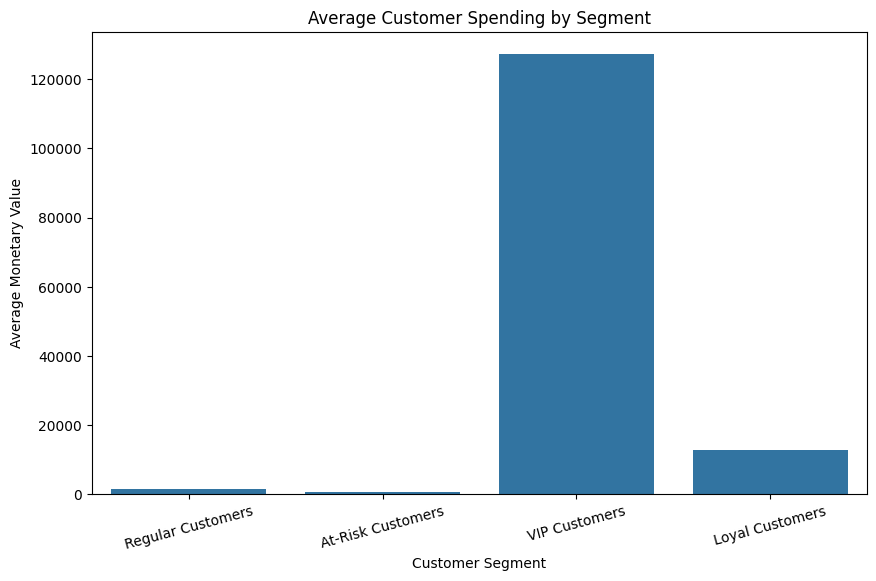

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_profile,
    x='Segment',
    y='Avg_Monetary'
)

plt.title('Average Customer Spending by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')

plt.xticks(rotation=15)

plt.show()

# 💡 Marketing Recommendations by Customer Segment

### 🏆 VIP Customers
- Provide exclusive rewards and premium loyalty benefits.
- Offer personalized recommendations and early access to new products.
- Focus on customer retention through dedicated support and special offers.

### 🤝 Loyal Customers
- Introduce loyalty programs and reward points.
- Encourage higher spending through cross-selling and upselling strategies.
- Provide personalized discounts and product recommendations.

### 👥 Regular Customers
- Use targeted promotions to encourage more frequent purchases.
- Recommend related products based on previous purchases.
- Offer discounts or incentives to increase customer engagement and spending.

### ⚠️ At-Risk Customers
- Launch re-engagement campaigns through email or personalized offers.
- Provide limited-time discounts to encourage customers to return.
- Identify possible reasons for inactivity and improve retention strategies.

# 📊 Key Insights

1. **Regular Customers represent the largest segment**, with 3,054 customers. These customers show moderate purchasing activity and provide an opportunity to increase purchase frequency and spending.

2. **At-Risk Customers represent 1,067 customers** and have the highest average recency of 248 days, indicating that they have not purchased recently and may require re-engagement strategies.

3. **VIP Customers are a small but highly valuable segment**, consisting of only 13 customers. They have the highest purchase frequency and monetary value, making customer retention extremely important.

4. **Loyal Customers demonstrate strong purchasing behaviour**, with an average frequency of 22.33 purchases and average spending of 12,709.09.

5. The analysis shows that **customer value is highly concentrated**, with a small number of VIP and Loyal customers contributing significantly more than the larger Regular Customer segment.

# 📌 Conclusion

This customer segmentation analysis used the **RFM model and K-Means clustering** to divide 4,338 customers into four distinct customer segments based on their purchasing behaviour.

The analysis identified **Regular Customers, At-Risk Customers, VIP Customers, and Loyal Customers**. Each segment demonstrates different characteristics in terms of recency, purchase frequency, and total spending.

The results show that while Regular Customers represent the largest customer group, VIP and Loyal Customers generate significantly higher value. At-Risk Customers require targeted re-engagement strategies to encourage them to return.

These insights can help businesses develop more effective **customer retention, personalized marketing, loyalty, cross-selling, and re-engagement strategies**, ultimately supporting improved customer relationships and business performance.
